In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr  # Assuming you are still loading your NetCDF files!

In [2]:
###This is for MAE###
# Reference baselines recorded from model output:
BASELINES = {
    "USA_Land": 0.126581,
    "USA_Water": 0.179681,
    "Amazon_Land": 0.267847,
    "Amazon_Water": 0.057084
}

# Clean feature labels map
NAME_MAPPING = {
    'cape': 'CAPE',
    'cldfrac': 'Convective Cloud Fraction @ 440hPa',
    'cldht': 'Convective Cloud Height',
    'crh': 'Column Relative Humidity',
    'iceflux': 'Max. Convective Ice Flux',
    'iwc440': 'Ice Water Content @ 440',
    'lcl': 'LCL',
    'massflux': 'Cummulative Mass Flux @ 440hPa',
    'maxcloudfrac': 'Max. Convective Cloud Fraction',
    'mseratio': 'Moist Static Energy Ratio',
    'precon': 'Deep Convective Precip.',
    'tlapse': 'Temperature Lapse Rate'
}

#Load Data
df_usa = pd.read_csv("USA_PFI_Land_Water.csv")
df_amazon = pd.read_csv("Amazon_PFI_Land_Water.csv")

In [6]:
def prepare_panel_data(df, imp_col, std_col, baseline):
    panel_data = []
    for feat in df['Feature'].unique():
        r_val = df.loc[df['Feature'] == feat, imp_col].values[0]
        std_val = df.loc[df['Feature'] == feat, std_col].values[0]

        # CSV values (Baseline - Shuffled) represent performance change directly
        r_pct = (r_val / baseline) * 100.0
        std_pct = (std_val / baseline) * 100.0

        clean_name = NAME_MAPPING.get(feat, feat)

        panel_data.append({
            "Feature": clean_name,
            "Performance Impact %": r_pct,
            "Error %": std_pct
        })
    
    # Sort descending so the largest performance drop (-19.9%) appears at the TOP
    return pd.DataFrame(panel_data).sort_values(by="Performance Impact %", ascending=False)

Figure successfully saved to: SEILER_Net_Feature_Importance_Performance_MAE.png


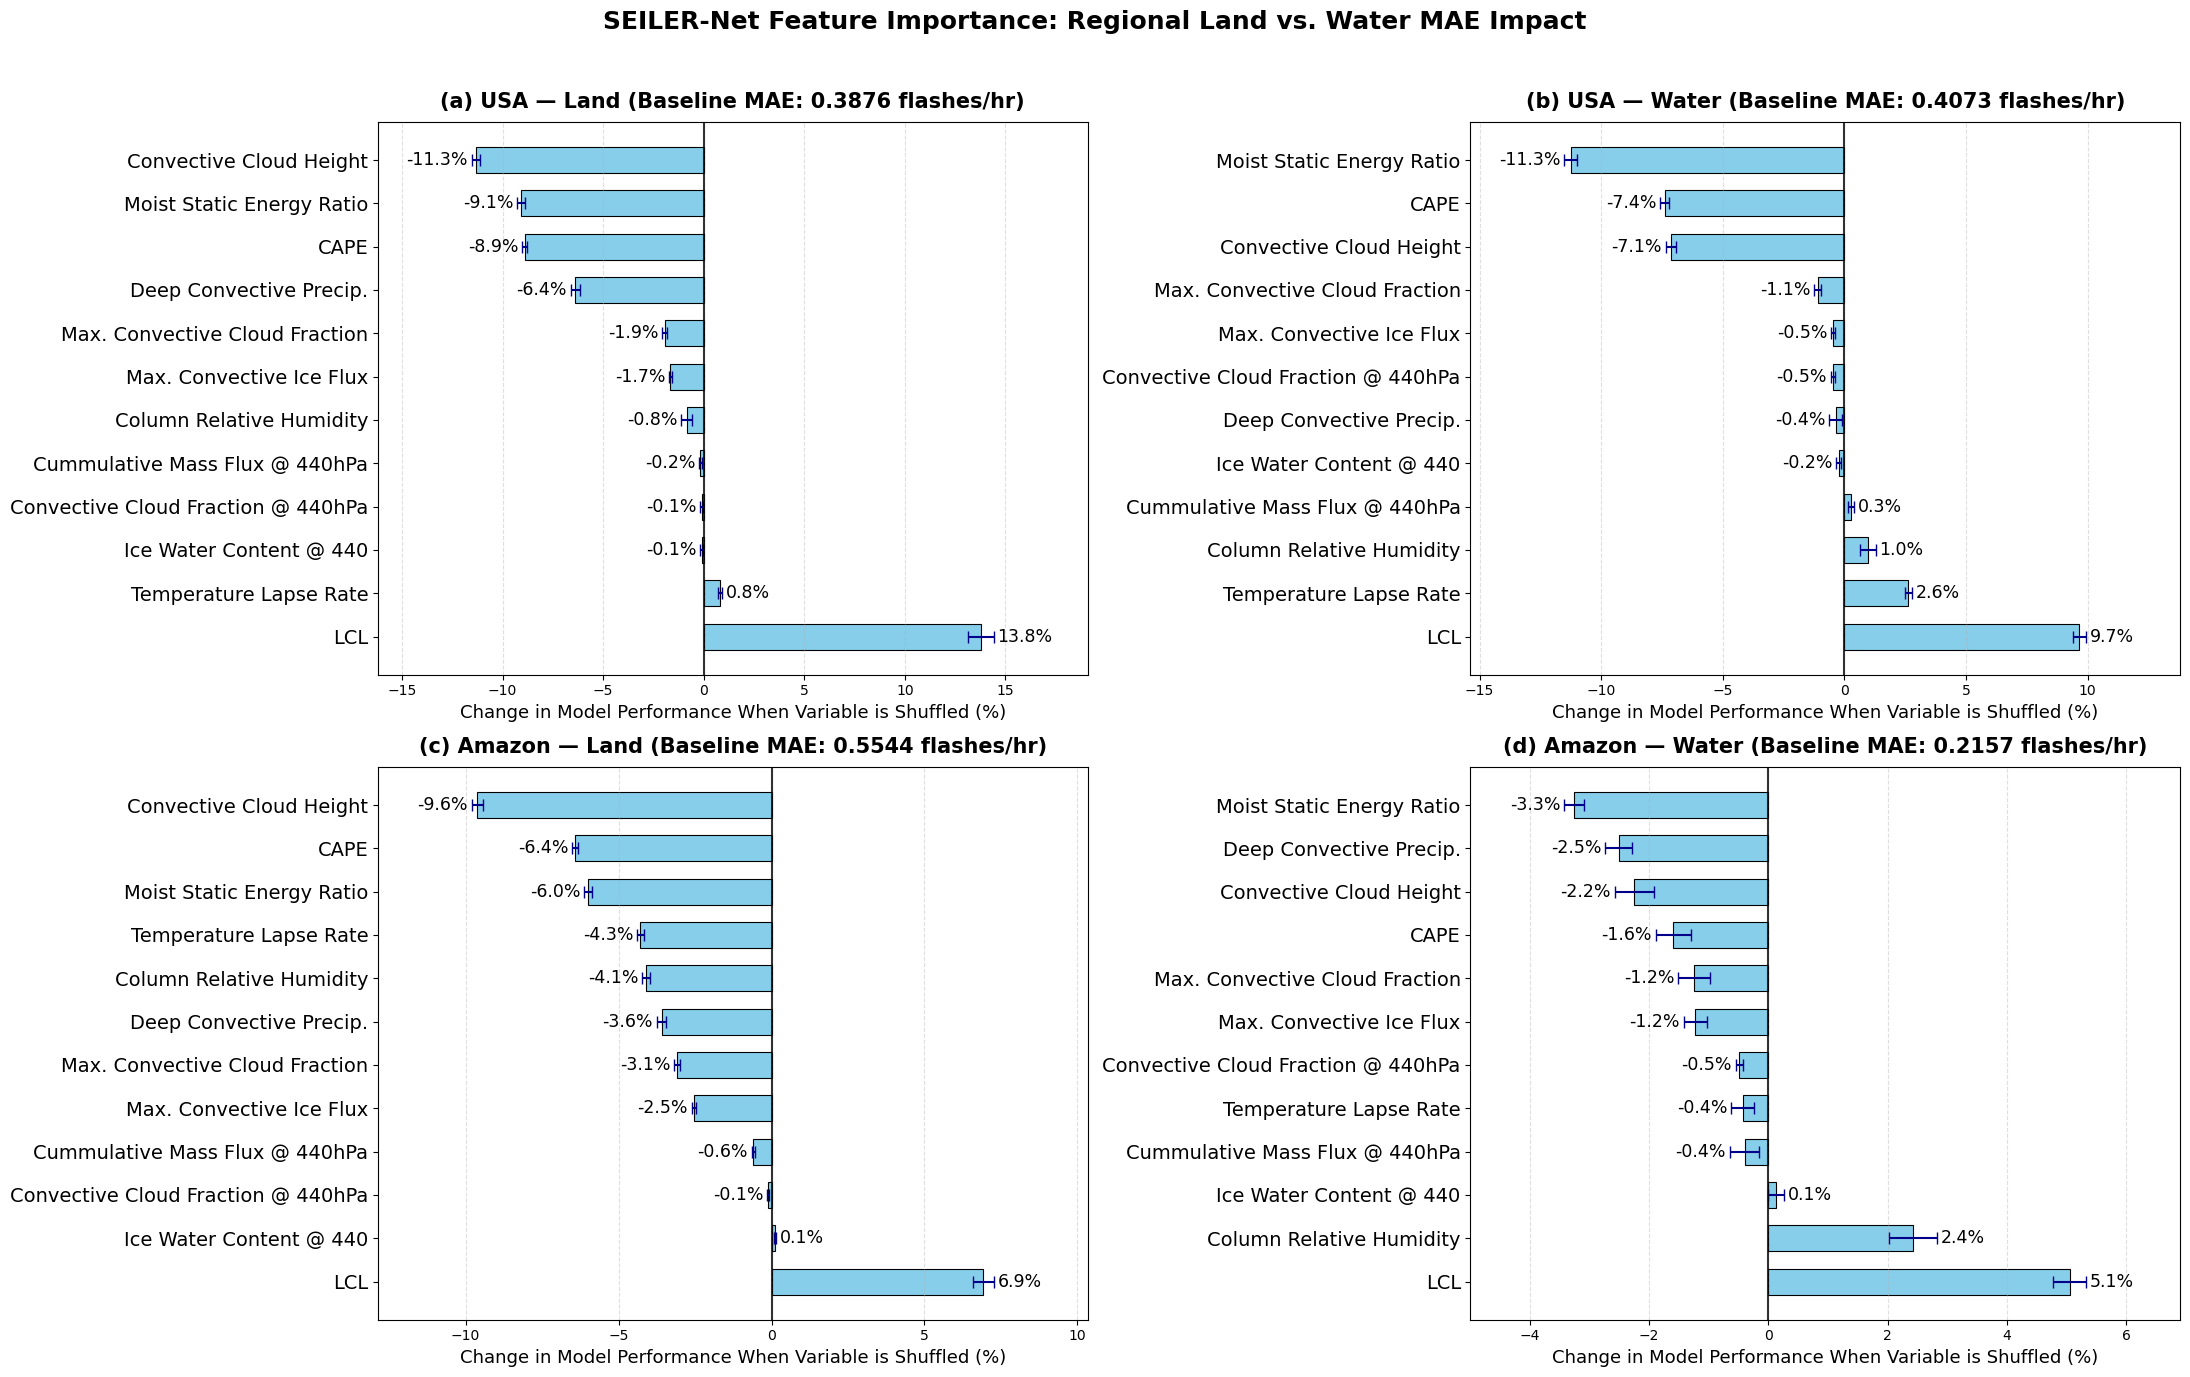

In [19]:
UNIT = "flashes/hr"
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(22, 14), sharey=False)

panels = [
    {
        "ax": axes[0, 0],
        "title": f"(a) USA — Land (Baseline MAE: {BASELINES['USA_Land']:.4f} {UNIT})",
        "df": df_usa,
        "imp_col": "USA_Imp_Land",
        "std_col": "USA_Std_Land",
        "baseline": BASELINES["USA_Land"],
        "color": "skyblue"
    },
    {
        "ax": axes[0, 1],
        "title": f"(b) USA — Water (Baseline MAE: {BASELINES['USA_Water']:.4f} {UNIT})",
        "df": df_usa,
        "imp_col": "USA_Imp_Water",
        "std_col": "USA_Std_Water",
        "baseline": BASELINES["USA_Water"],
        "color": "skyblue"
    },
    {
        "ax": axes[1, 0],
        "title": f"(c) Amazon — Land (Baseline MAE: {BASELINES['Amazon_Land']:.4f} {UNIT})",
        "df": df_amazon,
        "imp_col": "Amazon_Imp_Land",
        "std_col": "Amazon_Std_Land",
        "baseline": BASELINES["Amazon_Land"],
        "color": "skyblue"
    },
    {
        "ax": axes[1, 1],
        "title": f"(d) Amazon — Water (Baseline MAE: {BASELINES['Amazon_Water']:.4f} {UNIT})",
        "df": df_amazon,
        "imp_col": "Amazon_Imp_Water",
        "std_col": "Amazon_Std_Water",
        "baseline": BASELINES["Amazon_Water"],
        "color": "skyblue"
    }
]

for panel in panels:
    ax = panel["ax"]
    df_panel = prepare_panel_data(panel["df"], panel["imp_col"], panel["std_col"], panel["baseline"])
    
    y = np.arange(len(df_panel))
    width = 0.60

    # Horizontal Bar Plot
    ax.barh(
        y, df_panel["Performance Impact %"], width,
        color=panel["color"], edgecolor='black', linewidth=0.8,
        xerr=df_panel["Error %"],
        error_kw={'ecolor': 'darkblue', 'capsize': 4, 'elinewidth': 1.5}
    )

    # Panel Formatting
    ax.set_title(panel["title"], fontsize=15, fontweight='bold', pad=10)
    ax.set_yticks(y)
    ax.set_yticklabels(df_panel["Feature"], fontsize=14)
    ax.set_xlabel("Change in Model Performance When Variable is Shuffled (%)", fontsize=13)

    # Zero line & background grid
    ax.axvline(0, color='black', linewidth=1.5, alpha=0.8)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    # Calculate padding based on error bar extents
    x_min = (df_panel["Performance Impact %"] - df_panel["Error %"]).min()
    x_max = (df_panel["Performance Impact %"] + df_panel["Error %"]).max()
    padding = (x_max - x_min) * 0.18 if (x_max - x_min) > 0 else 5
    ax.set_xlim(x_min - padding, x_max + padding)

    # Percentage data labels placed past the error bars
    for i, (r, err) in enumerate(zip(df_panel["Performance Impact %"], df_panel["Error %"])):
        offset = err + (padding * 0.04)
        if r < 0:
            text_x = r - offset
            align = 'right'
        else:
            text_x = r + offset
            align = 'left'
        
        ax.text(text_x, i, f'{r:.1f}%', va='center', ha=align, fontsize=12.5)

fig.suptitle("SEILER-Net Feature Importance: Regional Land vs. Water MAE Impact", fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])

output_path = "SEILER_Net_Feature_Importance_Performance_MAE.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure successfully saved to: {output_path}")

plt.show()

In [13]:
###This is for RMSEE###
# Reference baselines recorded from model output:
BASELINES = {
    "USA_Land": 0.387601,
    "USA_Water": 0.407286,
    "Amazon_Land": 0.554408,
    "Amazon_Water": 0.215713
}

# Clean feature labels map
NAME_MAPPING = {
    'cape': 'CAPE',
    'cldfrac': 'Convective Cloud Fraction @ 440hPa',
    'cldht': 'Convective Cloud Height',
    'crh': 'Column Relative Humidity',
    'iceflux': 'Max. Convective Ice Flux',
    'iwc440': 'Ice Water Content @ 440',
    'lcl': 'LCL',
    'massflux': 'Cummulative Mass Flux @ 440hPa',
    'maxcloudfrac': 'Max. Convective Cloud Fraction',
    'mseratio': 'Moist Static Energy Ratio',
    'precon': 'Deep Convective Precip.',
    'tlapse': 'Temperature Lapse Rate'
}

#Load Data
df_usa = pd.read_csv("USA_PFI_Land_Water_RMSE.csv")
df_amazon = pd.read_csv("Amazon_PFI_Land_Water_RMSE.csv")

Figure successfully saved to: SEILER_Net_Feature_Importance_Performance_RMSE.png


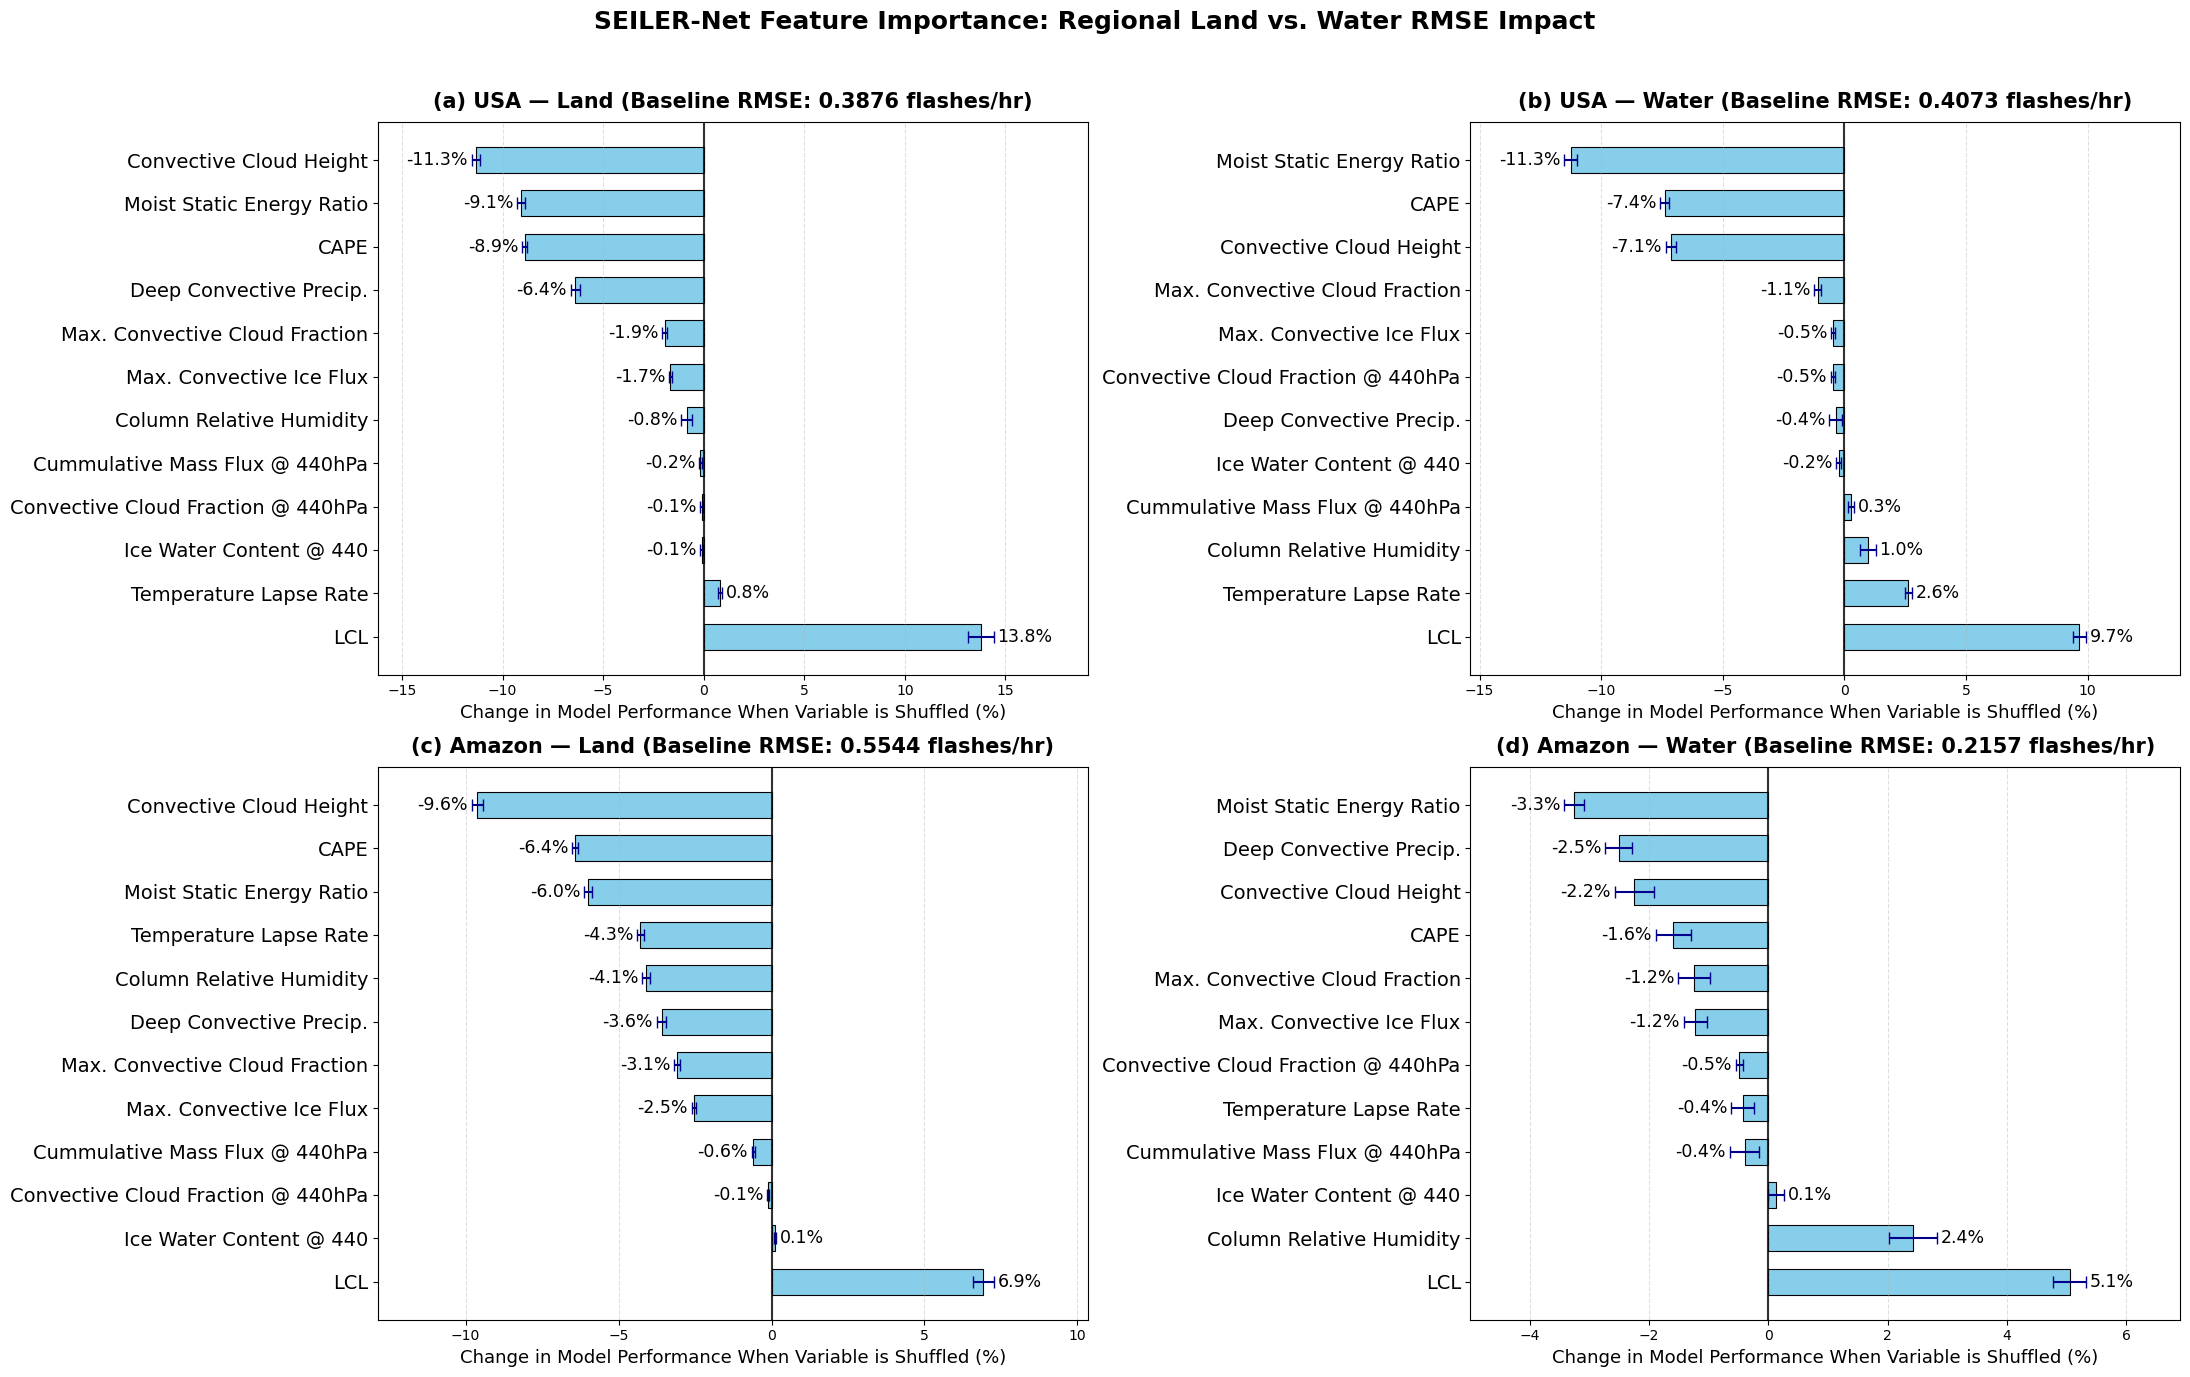

In [18]:
UNIT = "flashes/hr"
fig, axes = plt.subplots(2, 2, figsize=(22, 14), sharey=False)

panels = [
    {
        "ax": axes[0, 0],
        "title": f"(a) USA — Land (Baseline RMSE: {BASELINES['USA_Land']:.4f} {UNIT})",
        "df": df_usa,
        "imp_col": "USA_Imp_Land",
        "std_col": "USA_Std_Land",
        "baseline": BASELINES["USA_Land"],
        "color": "skyblue"
    },
    {
        "ax": axes[0, 1],
        "title": f"(b) USA — Water (Baseline RMSE: {BASELINES['USA_Water']:.4f} {UNIT})",
        "df": df_usa,
        "imp_col": "USA_Imp_Water",
        "std_col": "USA_Std_Water",
        "baseline": BASELINES["USA_Water"],
        "color": "skyblue"
    },
    {
        "ax": axes[1, 0],
        "title": f"(c) Amazon — Land (Baseline RMSE: {BASELINES['Amazon_Land']:.4f} {UNIT})",
        "df": df_amazon,
        "imp_col": "Amazon_Imp_Land",
        "std_col": "Amazon_Std_Land",
        "baseline": BASELINES["Amazon_Land"],
        "color": "skyblue"
    },
    {
        "ax": axes[1, 1],
        "title": f"(d) Amazon — Water (Baseline RMSE: {BASELINES['Amazon_Water']:.4f} {UNIT})",
        "df": df_amazon,
        "imp_col": "Amazon_Imp_Water",
        "std_col": "Amazon_Std_Water",
        "baseline": BASELINES["Amazon_Water"],
        "color": "skyblue"
    }
]

for panel in panels:
    ax = panel["ax"]
    df_panel = prepare_panel_data(panel["df"], panel["imp_col"], panel["std_col"], panel["baseline"])
    
    y = np.arange(len(df_panel))
    width = 0.60

    # Horizontal Bar Plot
    ax.barh(
        y, df_panel["Performance Impact %"], width,
        color=panel["color"], edgecolor='black', linewidth=0.8,
        xerr=df_panel["Error %"],
        error_kw={'ecolor': 'darkblue', 'capsize': 4, 'elinewidth': 1.5}
    )

    # Panel Formatting
    ax.set_title(panel["title"], fontsize=15, fontweight='bold', pad=10)
    ax.set_yticks(y)
    ax.set_yticklabels(df_panel["Feature"], fontsize=14)
    ax.set_xlabel("Change in Model Performance When Variable is Shuffled (%)", fontsize=13)

    # Zero line & background grid
    ax.axvline(0, color='black', linewidth=1.5, alpha=0.8)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    # Calculate padding based on error bar extents
    x_min = (df_panel["Performance Impact %"] - df_panel["Error %"]).min()
    x_max = (df_panel["Performance Impact %"] + df_panel["Error %"]).max()
    padding = (x_max - x_min) * 0.18 if (x_max - x_min) > 0 else 5
    ax.set_xlim(x_min - padding, x_max + padding)

    # Percentage data labels placed past the error bars
    for i, (r, err) in enumerate(zip(df_panel["Performance Impact %"], df_panel["Error %"])):
        offset = err + (padding * 0.04)
        if r < 0:
            text_x = r - offset
            align = 'right'
        else:
            text_x = r + offset
            align = 'left'
        
        ax.text(text_x, i, f'{r:.1f}%', va='center', ha=align, fontsize=12.5)

fig.suptitle("SEILER-Net Feature Importance: Regional Land vs. Water RMSE Impact", fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])

output_path = "SEILER_Net_Feature_Importance_Performance_RMSE.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure successfully saved to: {output_path}")

plt.show()